In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
import ipywidgets as widgets
from IPython.display import display

In [6]:
# Loading the cleaned Datasheet

df= pd.read_csv("cleaned_titanic-Copy1.csv")

Part 1 - Data Understanding

In [7]:
# Display first 5 rows

df.head()

,Passenger_ID,Survived,Passenger_Class,Name,Sex,Age,Siblings_Spouses,Parents_Children,Ticket,Ticket_Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S


In [8]:
# Display last 5 rows

df.tail()


,Passenger_ID,Survived,Passenger_Class,Name,Sex,Age,Siblings_Spouses,Parents_Children,Ticket,Ticket_Fare,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27,0,0,211536,13.00,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,0,0,112053,30.00,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28,1,2,W./C. 6607,23.45,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26,0,0,111369,30.00,C
890,891,0,3,"Dooley, Mr. Patrick",male,32,0,0,370376,7.75,Q


In [9]:
# Display the number of rows and columns

print("Dataset Shape:", df.shape)


Dataset Shape: (891, 11)


In [12]:
# Display all column names

df.columns

Index(['Passenger_ID', 'Survived', 'Passenger_Class', 'Name', 'Sex', 'Age',
       'Siblings_Spouses', 'Parents_Children', 'Ticket', 'Ticket_Fare',
       'Embarked'],
      dtype='object')

In [13]:
# Check data information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Passenger_ID      891 non-null    int64  
 1   Survived          891 non-null    int64  
 2   Passenger_Class   891 non-null    int64  
 3   Name              891 non-null    object 
 4   Sex               891 non-null    object 
 5   Age               891 non-null    int64  
 6   Siblings_Spouses  891 non-null    int64  
 7   Parents_Children  891 non-null    int64  
 8   Ticket            891 non-null    object 
 9   Ticket_Fare       891 non-null    float64
 10  Embarked          891 non-null    object 
dtypes: float64(1), int64(6), object(4)
memory usage: 76.7+ KB


In [14]:
# Display summary statistics 

df.describe()

,Passenger_ID,Survived,Passenger_Class,Age,Siblings_Spouses,Parents_Children,Ticket_Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.345679,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.028212,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [16]:
# Check the number of missing values 

df.isnull().sum()

Passenger_ID        0
Survived            0
Passenger_Class     0
Name                0
Sex                 0
Age                 0
Siblings_Spouses    0
Parents_Children    0
Ticket              0
Ticket_Fare         0
Embarked            0
dtype: int64

In [20]:
# Check duplicates

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Description 

* The Titanic dataset contains information about passengers who travelled on the Titanic.
* It includes details like age, gender, passenger class, fare, family size, and survival status.
* The dataset has **891 rows and 12 columns** before adding the new features in Part 2.
* It contains both numerical and categorical data, which helps us compare different types of passengers.
* Overall, the dataset helps us understand the different factors that may have affected passenger survival.

 

Part 2 - Feature Engineering

In [21]:
# 1. Create the FamilySize column

df["FamilySize"] = df["Siblings_Spouses"] + df ["Parents_Children"]


In [22]:
# To check the added column
df [["Siblings_Spouses" , "Parents_Children", "FamilySize"]].head()

,Siblings_Spouses,Parents_Children,FamilySize
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0


Explanation
Family Size: I created this feature by adding the number of siblings/spouses and parents/children, plus 1 for the passenger themselves. It helps us see how many people were travelling together as a family.

In [33]:
# 2. Create the IsAlone 

def is_alone(row):
    if row["FamilySize"] == 1 or row["FamilySize"] == 0:
        return "Yes"
    else:
        return "No"

df["IsAlone"] = df.apply(is_alone,axis=1)
df.head()

,Passenger_ID,Survived,Passenger_Class,Name,Sex,Age,Siblings_Spouses,Parents_Children,Ticket,Ticket_Fare,Embarked,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S,1,Yes
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C,1,Yes
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S,0,Yes
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S,1,Yes
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S,0,Yes


Explanation
Is Alone: This feature shows whether a passenger was travelling alone or with someone else. It has two categories: Yes and No.

In [35]:
# 3. Create Age Group

def age_group(age):

    if age < 13:
        return "Child"

    elif age < 20:
        return "Teenager"

    elif age < 41:
        return "Adult"

    else:
        return "Senior Citizen"
        
df["AgeGroup"] = df["Age"].apply(age_group)
df[["Age", "AgeGroup"]].head()

,Age,AgeGroup
0,22,Adult
1,38,Adult
2,26,Adult
3,35,Adult
4,35,Adult


Explanation
Age Group: I divided passengers into different age categories: Child, Teenager, Adult, and Senior Citizen. This makes it easier to compare survival patterns between different age groups.

In [37]:
# 4. Create Fare Category

def fare_category(fare):
    if fare < 20:
        return "Low Fare"
    elif fare < 50:
        return "Medium Fare"
    else:
        return "High Fare"

df["FareCategory"] = df["Ticket_Fare"].apply(fare_category)

df[["Ticket_Fare", "FareCategory"]].head()

,Ticket_Fare,FareCategory
0,7.2500,Low Fare
1,71.2833,High Fare
2,7.9250,Low Fare
3,53.1000,High Fare
4,8.0500,Low Fare


Explanation
Fare Category: I created this feature by dividing passengers into different fare groups based on the amount they paid for their ticket.
The categories can be Low Fare, Medium Fare, and High Fare.
This makes it easier to compare passengers based on how much they paid for their tickets.

In [42]:
print(df["FareCategory"].value_counts())

FareCategory
Low Fare       515
Medium Fare    215
High Fare      161
Name: count, dtype: int64


In [41]:
# Apply changes and save neew file

df.to_csv("Cleaned_titanic (week 2).csv",index=1)  

Part 3 - Explanatory Data Analysis (EDA)

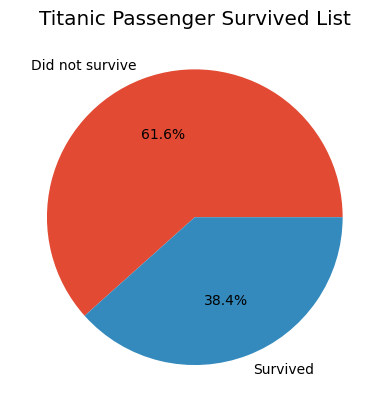

In [53]:
# Question 1: What percentage of passengers survived? Create an appropriate chart. Write your observation.

survival_percentage = df['Survived'].mean()*100


# For plotting
survival_counts = df['Survived'].value_counts()

plt.pie(
    survival_counts,
    labels = ['Did not survive', 'Survived'],
    autopct='%1.1f%%'
)
plt.title("Titanic Passenger Survived List")
plt.show()



Observation:
The results show that more passengers did not survive than those who survived. The overall survival rate is lower, which shows that surviving the Titanic accident was difficult for most passengers.

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


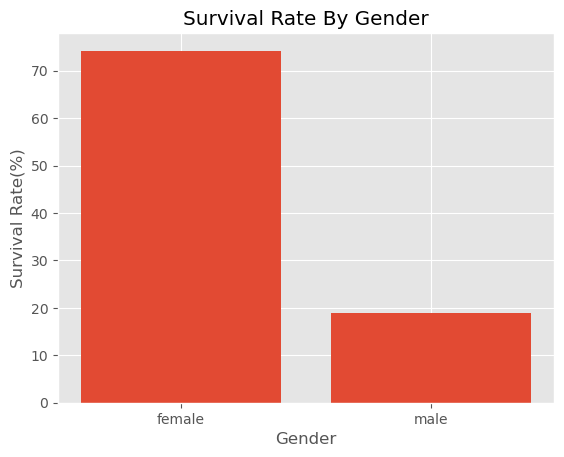

In [60]:
# Question 2: Which gender had the highest survival rate? Create a visualization. Explain your findings.

gender_survival = df.groupby('Sex')['Survived'].mean()* 100
print(gender_survival)

plt.bar(gender_survival.index, gender_survival.values)

plt.xlabel('Gender')
plt.ylabel('Survival Rate(%)')
plt.title('Survival Rate By Gender')

plt.show()

Observation:
The survival rate was different for males and females. Female passengers had a much higher survival rate than male passengers. This shows that gender had a strong effect on the chances of survival.

Passenger_Class
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


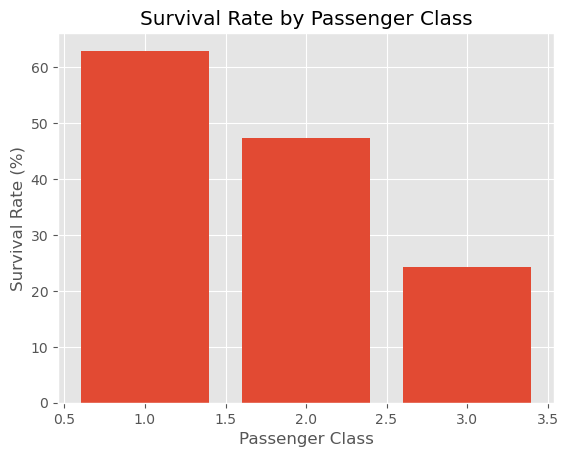

In [63]:
# Question 3: Which passenger class had the highest survival rate? Support your answer with a chart.

class_survival = df.groupby("Passenger_Class")["Survived"].mean() * 100
print(class_survival)

plt.bar(class_survival.index, class_survival.values)

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Passenger Class")

plt.show()

Observation:
Passengers from different classes had different survival rates. First-class passengers had the highest survival rate, while third-class passengers had the lowest. This shows that passenger class was an important factor in survival.

AgeGroup
Adult             35.924007
Child             57.971014
Senior Citizen    37.162162
Teenager          41.052632
Name: Survived, dtype: float64


Text(0.5, 1.0, 'Survival Rate by Age Group')

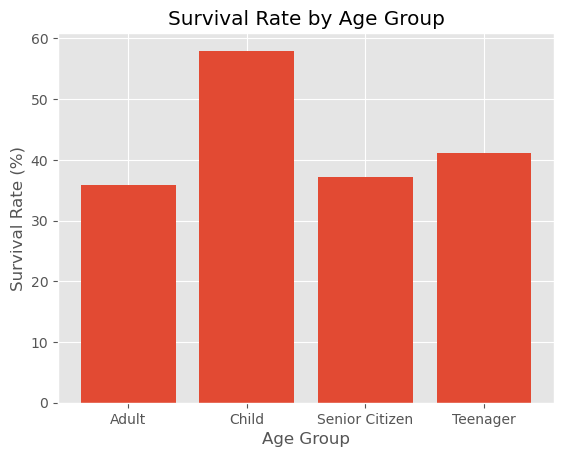

In [66]:
# Question 4: Does age affect survival? Use an appropriate visualization. Explain your conclusion.

age_survival = df.groupby('AgeGroup')['Survived'].mean()*100
print(age_survival)

plt.bar(age_survival.index, age_survival.values)

plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Age Group")


Observation:
The age distributions of survivors and non-survivors are different. Younger passengers had a better chance of survival in some cases, but age alone did not decide whether a passenger survived or not.

FareCategory
High Fare      67.701863
Low Fare       27.766990
Medium Fare    41.860465
Name: Survived, dtype: float64


Text(0.5, 1.0, 'Survival Rate by Fare Category')

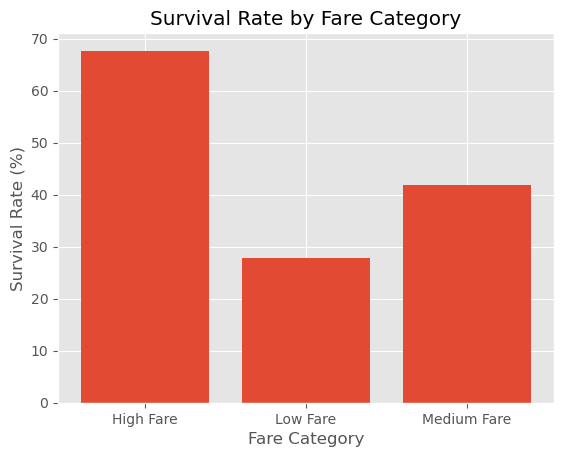

In [69]:
# Question 5: Does fare influence survival? Support your answer with visualization.

fare_survival = df.groupby('FareCategory')['Survived'].mean()*100
print(fare_survival)

plt.bar(fare_survival.index, fare_survival.values)

plt.xlabel("Fare Category")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Fare Category")


Observation:
Passengers who paid higher fares generally had better survival chances than passengers who paid lower fares. This may be because higher fares were usually connected with higher passenger classes.

IsAlone
No     46.632124
Yes    36.103152
Name: Survived, dtype: float64


Text(0.5, 1.0, 'Survival Rate by IsAlone Category')

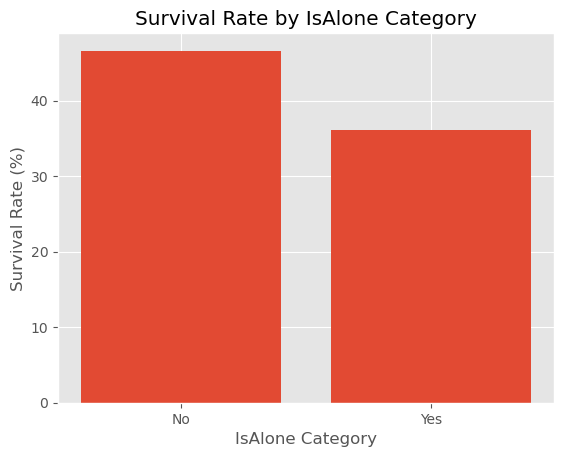

In [70]:
# Question 6: Did passengers travelling alone survive more often? Use a visualization. Explain your observation.

alone_survival = df.groupby('IsAlone')['Survived'].mean()*100
print(alone_survival)

plt.bar(alone_survival.index, alone_survival.values)

plt.xlabel("IsAlone Category")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by IsAlone Category")


Observation:
The survival rate was different for passengers travelling alone and those travelling with family. Passengers travelling with family had a different survival pattern compared with passengers who were alone. This shows that travelling status may have affected survival.

Survival Rate by Embarkation Port:
Embarked
-    100.000000
C     55.357143
Q     38.961039
S     33.695652
Name: Survived, dtype: float64


Text(0.5, 1.0, 'Survival Rate by Embarked Category')

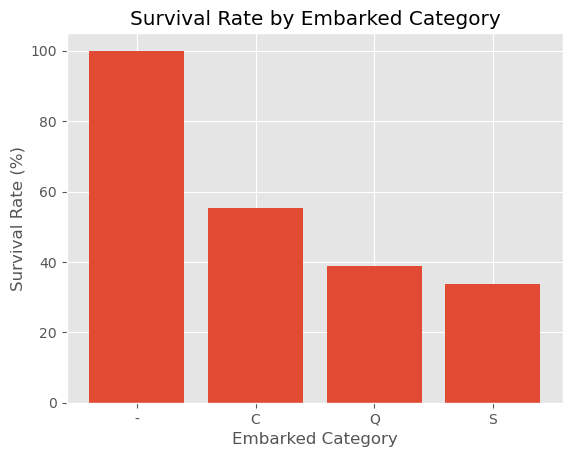

In [71]:
# Question 7: Which embarkation port had the highest survival rate? Create a chart and explain the result.

embarked_survival_rate = df.groupby("Embarked")["Survived"].mean() * 100
print("Survival Rate by Embarkation Port:")
print(embarked_survival_rate)

plt.bar(embarked_survival_rate.index, embarked_survival_rate.values)

plt.xlabel("Embarked Category")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Embarked Category")

Observation:
The survival rate was different for passengers from different embarkation ports. One port had a higher survival rate than the others. This difference may be connected to the types of passengers and classes travelling from each port.

Passenger_Class  First Class  Second Class  Third Class
FareCategory                                           
High Fare                140             7           14
Low Fare                   6           104          405
Medium Fare               70            73           72


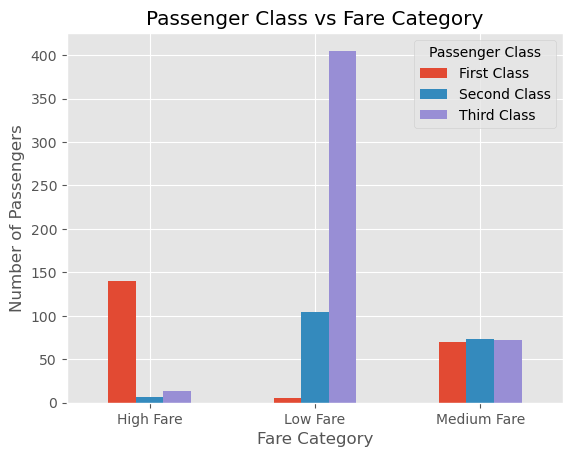

In [81]:
# Question 8: What is the relationship between passenger class and fare? Support your answer using an appropriate visualization.

fare_class = pd.crosstab(
    df["FareCategory"],
    df["Passenger_Class"]
)

# Rename Passenger Class values for better readability
fare_class = fare_class.rename(columns={
    1: "First Class",
    2: "Second Class",
    3: "Third Class"
})

print(fare_class)

fare_class.plot(kind="bar")

plt.xlabel("Fare Category")
plt.ylabel("Number of Passengers")
plt.title("Passenger Class vs Fare Category")

plt.legend(title="Passenger Class")

plt.xticks(rotation=0)

plt.show()

Observation:
There is a clear relationship between passenger class and fare. First-class passengers generally paid higher fares, while third-class passengers paid lower fares. This shows that fare was strongly related to passenger class.

In [89]:
# Question 9: Create a Correlation Heatmap. Explain: strongest positive correlation, strongest negative correlation, and any interesting observations.

# To check only columns with numerical values
df.select_dtypes(include='number').columns

Index(['Passenger_ID', 'Survived', 'Passenger_Class', 'Age',
       'Siblings_Spouses', 'Parents_Children', 'Ticket_Fare', 'FamilySize'],
      dtype='object')

Correlation Matrix:
                  Survived  Passenger_Class       Age  Siblings_Spouses  \
Survived          1.000000        -0.338481 -0.064909         -0.035322   
Passenger_Class  -0.338481         1.000000 -0.339999          0.083081   
Age              -0.064909        -0.339999  1.000000         -0.233066   
Siblings_Spouses -0.035322         0.083081 -0.233066          1.000000   
Parents_Children  0.081629         0.018443 -0.172745          0.414838   
FamilySize        0.016639         0.065997 -0.245593          0.890712   

                  Parents_Children  FamilySize  
Survived                  0.081629    0.016639  
Passenger_Class           0.018443    0.065997  
Age                      -0.172745   -0.245593  
Siblings_Spouses          0.414838    0.890712  
Parents_Children          1.000000    0.783111  
FamilySize                0.783111    1.000000  


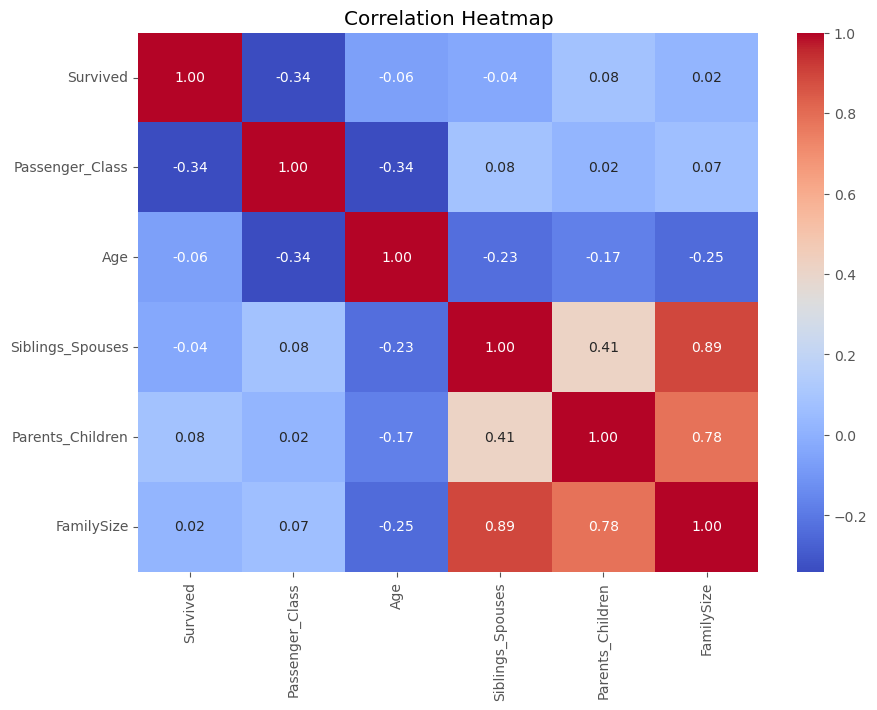

In [90]:
# Select the numerical columns needed for the correlation analysis
corr_data = df[
    [
        "Survived",
        "Passenger_Class",
        "Age",
        "Siblings_Spouses",
        "Parents_Children",
        "FamilySize"
    ]
]

correlation = corr_data.corr()

print("Correlation Matrix:")
print(correlation)

# Create the heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

# Display the heatmap
plt.show()

Observation:
The heatmap shows that some numerical variables have stronger relationships than others. Passenger class and fare show a noticeable relationship, while some other variables have weaker relationships. Overall, the heatmap helps us understand which variables are more closely connected.

FamilySize
0     30.353818
1     55.279503
2     57.843137
3     72.413793
4     20.000000
5     13.636364
6     33.333333
7      0.000000
10     0.000000
Name: Survived, dtype: float64


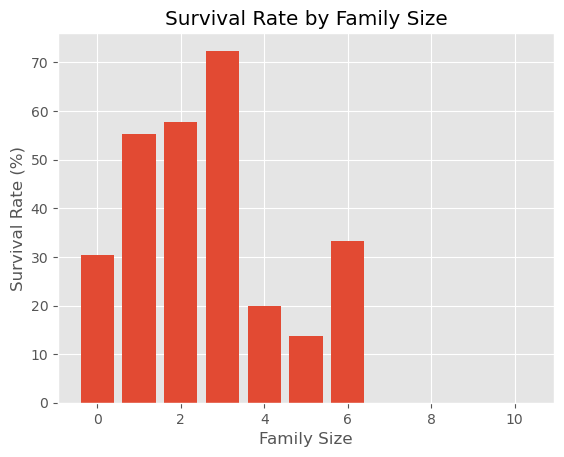

In [93]:
# Question 10: Create one additional analysis of your own (e.g. Family Size vs Survival, Age Group vs Passenger Class,
# Fare Category vs Survival, Family Size vs Fare, Age Group vs Gender). Explain your findings.

# Family Size vs Survival

df['FamilySize'].value_counts().sort_index()

family_survival = df.groupby('FamilySize')['Survived'].mean()*100

print(family_survival)

plt.bar(family_survival.index, family_survival.values)

plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Family Size")

plt.show()

Observation:
Survival rates changed for different family sizes. Passengers travelling with small families generally showed different survival patterns from those travelling alone or with larger families. This suggests that family size may have played a role in survival.

 Part 4 - Statistical Analysis

In [97]:
columns = ["Age", "Ticket_Fare", "FamilySize"]

for column in columns:
    print("\n", column)
    print("Mean:", df[column].mean())
    print("Median:", df[column].median())
    print("Mode:", df[column].mode()[0])
    print("Standard Deviation:", df[column].std())


 Age
Mean: 29.34567901234568
Median: 28.0
Mode: 28
Standard Deviation: 13.028211862792078

 Ticket_Fare
Mean: 32.204207968574636
Median: 14.4542
Mode: 8.05
Standard Deviation: 49.693428597180905

 FamilySize
Mean: 0.9046015712682379
Median: 0.0
Mode: 0
Standard Deviation: 1.6134585413550788


Part 5 -  Dashboard

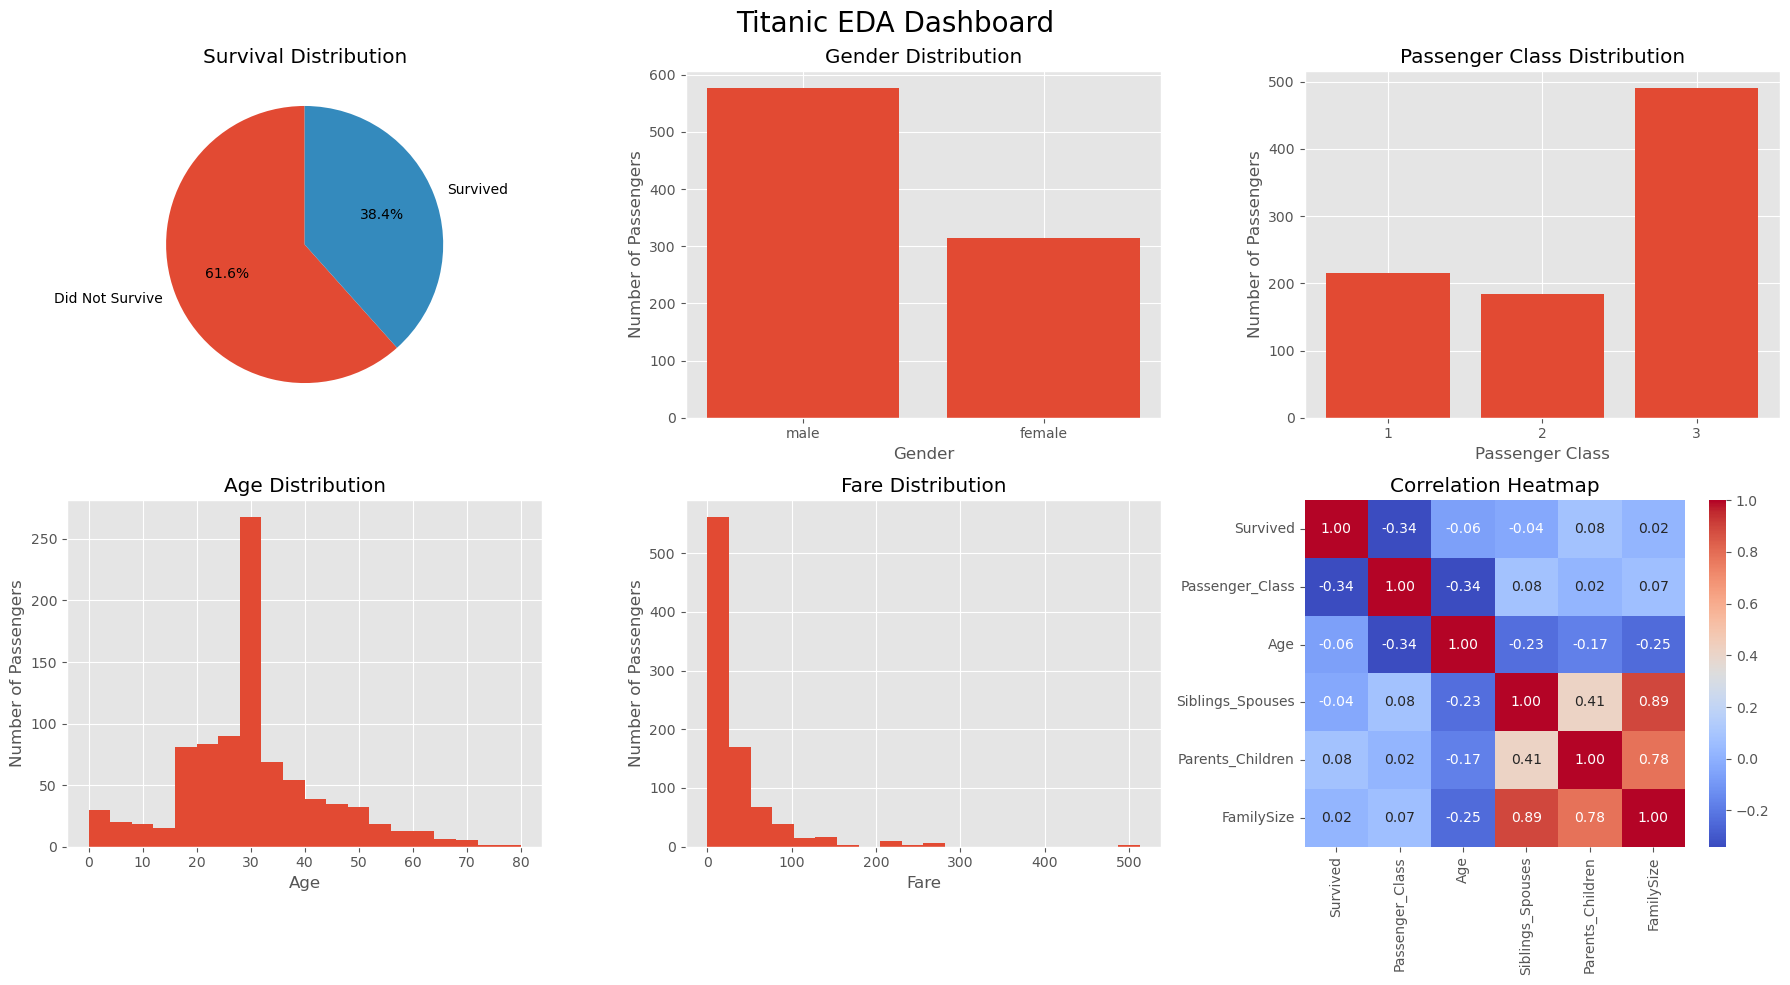

In [103]:
# Dashboard

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Survival Distribution

survival_counts = df["Survived"].value_counts()

axes[0, 0].pie(
    survival_counts,
    labels=["Did Not Survive", "Survived"],
    autopct="%1.1f%%",
    startangle=90
)

axes[0, 0].set_title("Survival Distribution")

# 2. Gender Distribution

gender_counts = df["Sex"].value_counts()

axes[0, 1].bar(
    gender_counts.index,
    gender_counts.values
)

axes[0, 1].set_title("Gender Distribution")
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_ylabel("Number of Passengers")


# 3. Passenger Class Distribution

class_counts = df["Passenger_Class"].value_counts().sort_index()

axes[0, 2].bar(
    class_counts.index.astype(str),
    class_counts.values
)

axes[0, 2].set_title("Passenger Class Distribution")
axes[0, 2].set_xlabel("Passenger Class")
axes[0, 2].set_ylabel("Number of Passengers")


# 4. Age Distribution

axes[1, 0].hist(
    df["Age"].dropna(),
    bins=20
)

axes[1, 0].set_title("Age Distribution")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Number of Passengers")


# 5. Fare Distribution

axes[1, 1].hist(
    df["Ticket_Fare"].dropna(),
    bins=20
)

axes[1, 1].set_title("Fare Distribution")
axes[1, 1].set_xlabel("Fare")
axes[1, 1].set_ylabel("Number of Passengers")


# 6. Correlation Heatmap

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[1, 2]
)

axes[1, 2].set_title("Correlation Heatmap")


# Dashboard Formatting

fig.suptitle(
    "Titanic EDA Dashboard",
    fontsize=20
)

plt.tight_layout()

plt.savefig("Visualizations/Titanic_Dashboard.png", bbox_inches="tight")

# Display the dashboard
plt.show()

 Bonus Challenge: Interactive Filter

In [115]:
# For passenger class
class_filter = widgets.Dropdown(
    options=["All", 1, 2, 3],
    value="All",
    description="Class:"
)

def filter_data(selected_class):
    
    if selected_class == "All":
        filtered_data = df
    else:
        filtered_data = df[df["Passenger_Class"] == selected_class]
    
    display(filtered_data.head(10))

widgets.interactive(
    filter_data,
    selected_class=class_filter
)

interactive(children=(Dropdown(description='Class:', options=('All', 1, 2, 3), value='All'), Output()), _dom_c…

In [116]:
# For survival status

survival_filter = widgets.Dropdown(
    options=["All", "Survived", "Did Not Survive"],
    value="All",
    description="Status:"
)

def filter_survival(selected_status):
    
    if selected_status == "All":
        filtered_data = df
    
    elif selected_status == "Survived":
        filtered_data = df[df["Survived"] == 1]
    
    else:
        filtered_data = df[df["Survived"] == 0]
    
    display(filtered_data.head(10))

widgets.interactive(
    filter_survival,
    selected_status=survival_filter
)

interactive(children=(Dropdown(description='Status:', options=('All', 'Survived', 'Did Not Survive'), value='A…